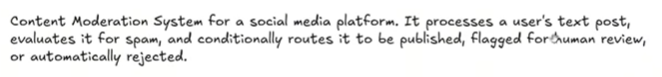

In [19]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated

In [20]:
class ModerationState(TypedDict):
    post_content:str
    user_reputation:str

    formatted_post:str
    content_flag:str
    result:str

In [21]:
def format_post(state:ModerationState):
    output=f"User {state['user_reputation']} says: {state["post_content"]}"
    return {
        "formatted_post":output
    }

In [22]:
def analyze_content(state:ModerationState):
    content=state['formatted_post'].lower()
    if "buy now" in content or "spam" in content:
        output="rejected"
    elif state["user_reputation"]=="new_user":
        output="Need_for_review"
    else:
        output="approved"
    return {
        "content_flag":output
    }

In [23]:
def approve_post(state:ModerationState):
    result="Post is approved"
    return {"result":result}

In [24]:
def flag_for_review(state:ModerationState):
    result="post is needed human review"
    return {"result":result}

In [25]:
def reject_post(state:ModerationState):
    result="Post is rejected"
    return {"result":result}

In [26]:
from typing import Literal
def condition(state:ModerationState)->Literal["approve_post","flag_for_review","reject_post"]:
    if state["content_flag"]=="approved":
        return "approve_post"
    elif state["content_flag"]=="Need_for_review":
        return "flag_for_review"
    else:
        return "reject_post"

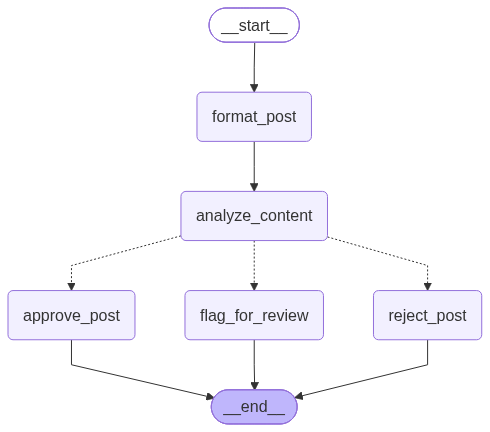

In [27]:
graph=StateGraph(ModerationState)

graph.add_node("format_post",format_post)
graph.add_node("analyze_content",analyze_content)
graph.add_node("approve_post",approve_post)
graph.add_node("flag_for_review",flag_for_review)
graph.add_node("reject_post",reject_post)

graph.add_edge(START,"format_post")
graph.add_edge("format_post","analyze_content")
graph.add_conditional_edges("analyze_content",condition)

workflow=graph.compile()
workflow


In [31]:
initial_state={
    "post_content":"check out the amazing product!",
    "user_reputation":"new_user"
}

final_state=workflow.invoke(initial_state)

In [32]:
from pprint import pprint

In [33]:
pprint(final_state)

{'content_flag': 'Need_for_review',
 'formatted_post': 'User new_user says: check out the amazing product!',
 'post_content': 'check out the amazing product!',
 'result': 'post is needed human review',
 'user_reputation': 'new_user'}


## Review Reply System LLM BASED

In [77]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

True

In [78]:
from pydantic import BaseModel,Field

class ReviewSchema(BaseModel):
    review:str=Field(description="Review")
    sentiment:Literal["positive","negative"]=Field(description="Give the sentiment for the following review")

class DiagnosisSchema(BaseModel):
    issue_type:Literal["UX","Performance","Bug","Support","Other"]
    tone:Literal["angry","frustrated","dissapointed","calm"]
    urgency:Literal["low","medium","high"]


In [79]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal["positive","negative"]
    diagnosis:dict
    response:str

In [80]:
model=init_chat_model(
    "openai/gpt-oss-120b",
    model_provider="groq",
    temperature=0.5
)
structured_model=model.with_structured_output(ReviewSchema)

In [81]:
def find_sentiment(state:ReviewState):
    prompt=f"Find the sentiment for the following review:{state["review"]}"
    response=structured_model.invoke(prompt)
    return {"sentiment":response.sentiment}

In [91]:
def run_diagnosis(state:ReviewState):
    prompt=f"Generate a detailed diagnosis on the following review {state["review"]}"
    structured_model=model.with_structured_output(DiagnosisSchema)
    response=structured_model.invoke(prompt)
    # answer={
    #     "issue_type":response.issue_type,
    #     "tone":response.tone,
    #     "urgency":response.urgency
    # }
    return {"diagnosis":{response}}


In [83]:
def positive_response(state:ReviewState):
    prompt=f"Generate a positive response for the following review {state["review"]}"
    response=model.invoke(prompt).content
    return {"response":response}

In [84]:
def negative_response(state:ReviewState):
    prompt=f"Generate a negative response for the following review {state["review"]} using the diagnosis {state["diagnosis"]}"
    response=model.invoke(prompt).content
    return {"response":response}

In [85]:
def check_condition(state:ReviewState)->Literal["run_diagnosis","positive_response"]:
    if state["sentiment"]=="positive":
        return "positive_response"
    else:
        return "run_diagnosis"

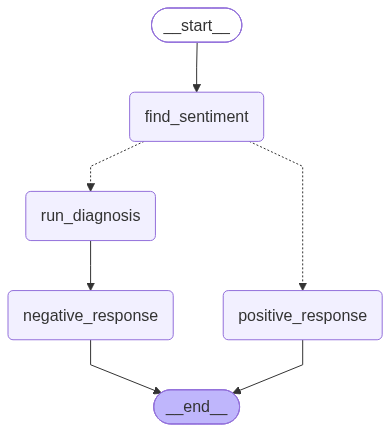

In [86]:
graph=StateGraph(ReviewState)

graph.add_node("find_sentiment",find_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_response",negative_response)
graph.add_node("positive_response",positive_response)

graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_condition)
graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("positive_response",END)
graph.add_edge("negative_response",END)

workflow=graph.compile()
workflow

In [87]:
initial_state={
    "review":"The product is good and works as expected. The interface is simple and easy to use, and the overall experience is smooth. However, the response time could be improved, and a few features could be more intuitive for new users. Overall, it is a useful product with good potential, but there is still room for improvement in performance and usability."

}

final_state=workflow.invoke(initial_state)

In [88]:
pprint(final_state)

{'response': 'Thank you so much for taking the time to share your thoughts '
             "with us! We're thrilled to hear that you find the product "
             'reliable, the interface clean and easy to navigate, and that the '
             'overall experience feels smooth. Your kind words about its '
             'usefulness and potential mean a lot to our team.\n'
             '\n'
             'We also appreciate your constructive feedback regarding response '
             'times and the intuitiveness of a few features for new users. '
             'Rest assured, we’re actively working on performance '
             'optimizations and refining the onboarding flow to make those '
             'areas even better.\n'
             '\n'
             'Your insights help us prioritize improvements that matter most '
             'to our users, and we’re excited to deliver an even more polished '
             'experience in upcoming updates. If you have any additional '
             'sug

In [92]:
initial_state={
    "review":"The product is extremely disappointing. It is very slow, crashes frequently, and the interface is confusing and difficult to navigate. Several features do not work properly, and customer support has been unresponsive. The overall experience has been frustrating, and I would not recommend this product."

}

final_state=workflow.invoke(initial_state)

In [93]:
pprint(final_state)

{'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': 'We’re extremely sorry to hear how badly this product has '
             'performed for you.\u202fYour experience—slow performance, '
             'frequent crashes, a confusing interface, broken features, and '
             'unresponsive support—is completely unacceptable, and we share '
             'your frustration.\u202fOur team has identified these problems as '
             'critical bugs and is treating them with the highest '
             'urgency.\u202fWe’re already working on a fix and will prioritize '
             'restoring full functionality as quickly as possible.\u202fIn the '
             'meantime, please reach out directly to\u202f'
             'support@ourcompany.com\u202fwith your case number so we can '
             'provide immediate, dedicated assistance and keep you updated on '
             'the progress.\u202fThank you for bringing this to our attention; '
           